**Labolatorium 05 - zbiory rozmyte**

*Kocjan Nikodem*

Wymagane importy

In [4]:
!pip install scikit-fuzzy
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.7 MB/s eta 0:00:00


**Zadanie 1**

W celu dokonania badań na zbiorach rozmytych wykorzystano bibliotekę skfuzzy i to jej metody będą pojawiały się w tym sprawozdaniu najczęściej.
Do wykonania zadania 1 potrzebne są trzy zmienne
- temperatura ->  wejście z zakresu do 15 do 36 stopni z krokiem 1 stopień
- wilgotność -> wejście z zakresu od 0 do 100 procent z krokiem co 1 procent
- woda -> wyjście jako ilość wody generowana przez system podlewania z zakresu od 0 do 26 litrów dziennie

In [5]:
temp = ctrl.Antecedent(np.arange(15, 36, 1), 'temperatura')
wilgotnosc = ctrl.Antecedent(np.arange(0, 101, 1), 'wilgotnosc')
woda = ctrl.Consequent(np.arange(0, 26, 1), 'ilosc_wody')

Kolejnym krokiem będzie przygotowanie funkcji przynależności dla zmiennych

Dla temperatury określono funkcję przynależności do zbiorów chłodno, ciepło, gorąco. Zakładamy chłodno od 15 do 23 z pełną przynależnością dla 15. Ciepło w zakresie od 20 do 28 z pełną przynależnością dla 24. Gorąco od 25 do 35 z pełną przynależnością dla 35

In [6]:
temp['chlodno'] = fuzz.trimf(temp.universe, [15, 15, 23])
temp['cieplo'] = fuzz.trimf(temp.universe, [20, 24, 28])
temp['goraco'] = fuzz.trimf(temp.universe, [25, 35, 35])

Dla wilgotności określono funkcję przynależności do zbiorów sucho, przecietnie, mokro. Zakładamy sucho od 0 do 40 z pełną przynależnością dla 0. Przecietnie w zakresie od 25 do 75 z pełną przynależnością dla 50. Mokro od 60 do 100 z pełną przynależnością dla 100

In [7]:
wilgotnosc['sucho'] = fuzz.trimf(wilgotnosc.universe, [0, 0, 40])
wilgotnosc['przecietnie'] = fuzz.trimf(wilgotnosc.universe, [25, 50, 75])
wilgotnosc['mokro'] = fuzz.trimf(wilgotnosc.universe, [60, 100, 100])

Dla wilgotności określono funkcję przynależności do zbiorów malo, srednio, duzo. Zakładamy malo od 0 do 10 z pełną przynależnością dla 0. Srednio w zakresie od 5 do 18 z pełną przynależnością dla 10. Duzo od 15 do 25 z pełną przynależnością dla 25.

In [8]:
woda['malo'] = fuzz.trimf(woda.universe, [0, 0, 10])
woda['srednio'] = fuzz.trimf(woda.universe, [5, 10, 18])
woda['duzo'] = fuzz.trimf(woda.universe, [15, 25, 25])

Na podstawie tabelki z polecenia uzupełniono zasady dla wody, zależnie od temperatury i wilgotności.

In [9]:
rule1 = ctrl.Rule(temp['chlodno'] & wilgotnosc['sucho'], woda['srednio'])
rule2 = ctrl.Rule(temp['chlodno'] & wilgotnosc['przecietnie'], woda['srednio'])
rule3 = ctrl.Rule(temp['chlodno'] & wilgotnosc['mokro'], woda['malo'])
rule4 = ctrl.Rule(temp['cieplo'] & wilgotnosc['sucho'], woda['duzo'])
rule5 = ctrl.Rule(temp['cieplo'] & wilgotnosc['przecietnie'], woda['srednio'])
rule6 = ctrl.Rule(temp['cieplo'] & wilgotnosc['mokro'], woda['malo'])
rule7 = ctrl.Rule(temp['goraco'] & wilgotnosc['sucho'], woda['duzo'])
rule8 = ctrl.Rule(temp['goraco'] & wilgotnosc['przecietnie'], woda['duzo'])
rule9 = ctrl.Rule(temp['goraco'] & wilgotnosc['mokro'], woda['srednio'])

Na podstawie regul oraz zaleznosci przygotowano model rozmyty

In [10]:
nawadnianie = ctrl.ControlSystemSimulation(ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9]))

Przygotowano dane do symulacji oraz zwizualizowania rezultatow. W celu osiągnięcia kwadratowej heat mapy, ustawiono krok wilgotności co 5 procent.

In [11]:
wilgotnosc_range = np.arange(0, 101, 5)
temp_range = np.arange(15, 36, 1)
wyniki = np.zeros((len(temp_range), len(wilgotnosc_range)))

Dla temperatur oraz wilgotnosci z wcześniej zdefiniowanego zakresu wykonano badanie. Rezultat zostanie przedstawiony w formie heat mapy.

In [12]:
for i, t in enumerate(temp_range):
    for j, w in enumerate(wilgotnosc_range):
        nawadnianie.input['temperatura'] = t
        nawadnianie.input['wilgotnosc'] = w
        nawadnianie.compute()
        wyniki[i, j] = nawadnianie.output['ilosc_wody']

Generowania wyników

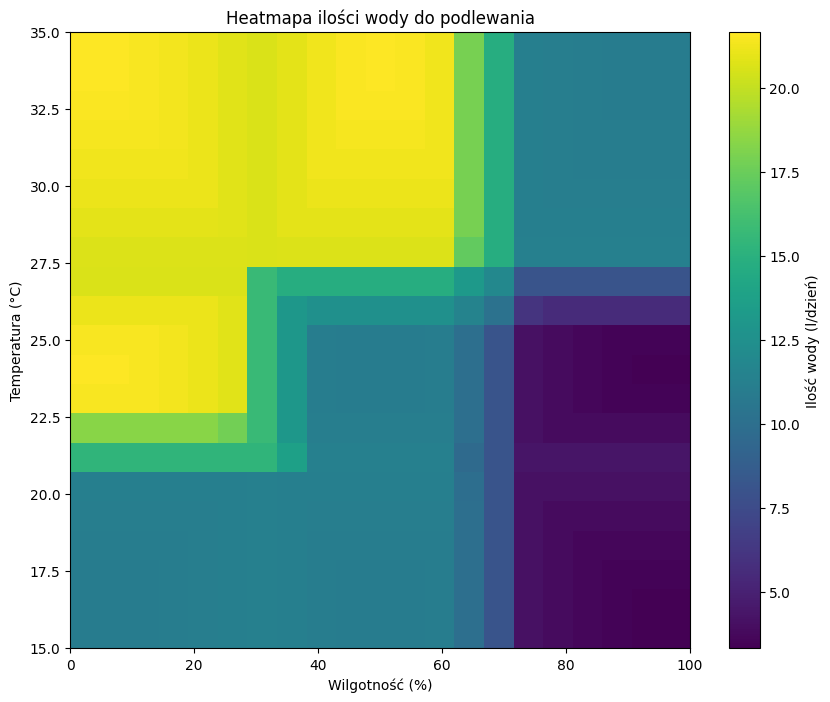

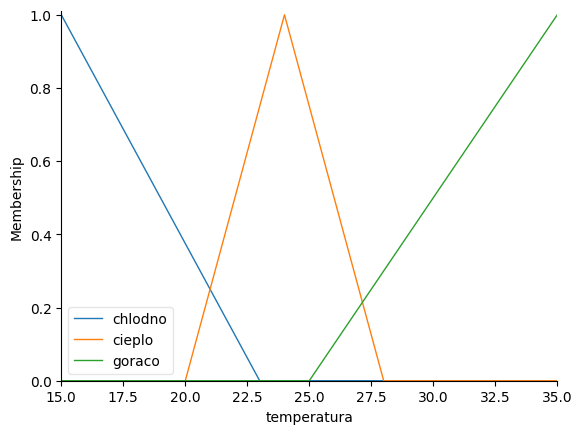

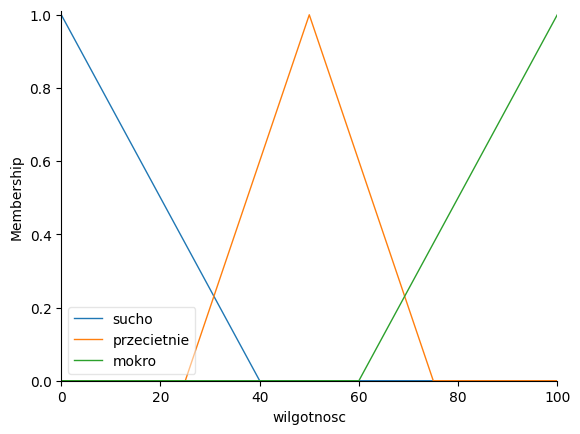

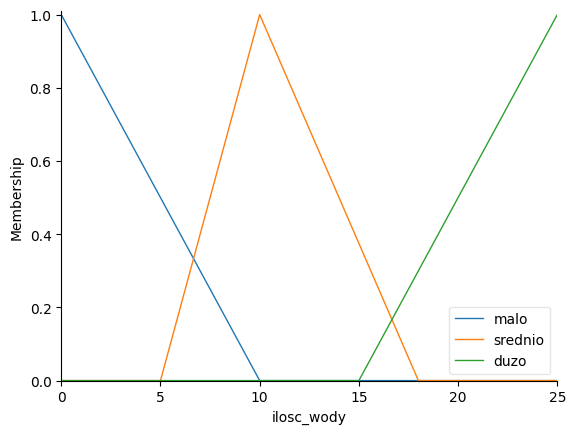

In [54]:
plt.figure(figsize=(10, 8))
plt.imshow(wyniki, cmap='viridis', extent=[0, 100, 15, 35], origin='lower', aspect='auto')
plt.colorbar(label='Ilość wody (l/dzień)')
plt.xlabel('Wilgotność (%)')
plt.ylabel('Temperatura (°C)')
plt.title('Heatmapa ilości wody do podlewania')
plt.show()

temp.view()
wilgotnosc.view()
woda.view()

**Zadanie 2**

Celem badania jest propozycja dowolnego rozmytego systemu wnioskowania. Wymagane są trzy zmienne wejśicowe i każda z nich podzielona na conajmniej trzy zbiory rozmyte.

Opis wybranego zagadnienia:
System rozmyty mający na celu zaproponowanie dawki kofeiny dla osoby potrzebującej na podstawie:
- czas od ostatniego spożycia, bądź ostatniej sesji snu ( 0 - 24h )
- poziom zmęczenia ( skala 1 - 10 )
- ilość zaległych sprawozdań z MIO ( 0 - 5 )

Zbiór danych wyjściowych to zakres kofeiny od 0 do 200 mg z wyciągniętymi kategoriami:
- puszka dzik mango 0 kofeiny
- puszka red bull 250ml
- puszka red bull 330ml
- puszka dzik tropic 200mg kofeiny bomba

Zdefniowanie zbioru danych wejściowych oraz wyjściowych

In [51]:
czas = ctrl.Antecedent(np.arange(0, 25, 1), 'czas_od_spoczynku')
zmeczenie = ctrl.Antecedent(np.arange(1, 11, 1), 'poziom_zmeczenia')
sprawozdania = ctrl.Antecedent(np.arange(0, 6, 1), 'ilosc_sprawozdan')
kofeina = ctrl.Consequent(np.arange(0, 201, 1), 'kofeina')

Uzuppełnienie funkcji czasu na podstawie ilościu godzin od snu / dawki kofeiny. Założono, że po 8 godzinach od ostatniej kawy, bądź od obudzenia się, jest odpowiednia pora na dawkę kofeiny

In [36]:
czas['niedawno'] = fuzz.trimf(czas.universe, [0, 0, 12])
czas['srednio'] = fuzz.trimf(czas.universe, [6, 8, 20])
czas['dawno'] = fuzz.trimf(czas.universe, [12, 24, 24])

Funkcja zmęczenia jest mocno subiektywna, dlatego dane rozłożono symetrycznie. Skala ( 1 - 10 ) oznacza 1 -> brak zmęczenia, 10 -> duże zmęczenie.

In [37]:
zmeczenie['niskie'] = fuzz.trimf(zmeczenie.universe, [1, 1, 4])
zmeczenie['srednie'] = fuzz.trimf(zmeczenie.universe, [3, 5.5, 8])
zmeczenie['wysokie'] = fuzz.trimf(zmeczenie.universe, [7, 10, 10])

Funkcja ilości zaległych sprawozdań.

In [38]:
sprawozdania['brak'] = fuzz.trimf(sprawozdania.universe, [0, 0, 1])
sprawozdania['troche'] = fuzz.trimf(sprawozdania.universe, [1, 2, 4])
sprawozdania['duzo'] = fuzz.trimf(sprawozdania.universe, [3, 5, 5])

Wyniki kofeiny rozłożone zgodnie z kategoriami opisanymi na początku zadania.

In [39]:
kofeina['dzik_mango_0_kofeiny'] = fuzz.trimf(kofeina.universe, [0, 0, 50])
kofeina['redbull_250ml'] = fuzz.trimf(kofeina.universe, [25, 75, 125])
kofeina['redbull_330ml'] = fuzz.trimf(kofeina.universe, [100, 150, 175])
kofeina['dzik_tropic_200mg_kofeiny_bomba'] = fuzz.trimf(kofeina.universe, [150, 200, 200])

Zdefiniowanie zasad

In [40]:
rule1 = ctrl.Rule(czas['niedawno'] & zmeczenie['niskie'] & sprawozdania['brak'], kofeina['dzik_mango_0_kofeiny'])
rule2 = ctrl.Rule(czas['niedawno'] & zmeczenie['wysokie'] & sprawozdania['duzo'], kofeina['redbull_330ml'])
rule3 = ctrl.Rule(czas['niedawno'] & zmeczenie['srednie'] & sprawozdania['troche'], kofeina['redbull_250ml'])
rule4 = ctrl.Rule(czas['srednio'] & zmeczenie['srednie'] & sprawozdania['troche'], kofeina['redbull_250ml'])
rule5 = ctrl.Rule(czas['srednio'] & zmeczenie['wysokie'] & sprawozdania['duzo'], kofeina['dzik_tropic_200mg_kofeiny_bomba'])
rule6 = ctrl.Rule(czas['srednio'] & zmeczenie['niskie'] & sprawozdania['troche'], kofeina['redbull_250ml'])
rule7 = ctrl.Rule(czas['dawno'] & zmeczenie['wysokie'] & sprawozdania['duzo'], kofeina['dzik_tropic_200mg_kofeiny_bomba'])
rule8 = ctrl.Rule(czas['dawno'] & zmeczenie['niskie'] & sprawozdania['brak'], kofeina['redbull_250ml'])
rule9 = ctrl.Rule(czas['dawno'] & zmeczenie['srednie'] & sprawozdania['duzo'], kofeina['redbull_330ml'])
rule10 = ctrl.Rule(czas['dawno'] & zmeczenie['srednie'] & sprawozdania['brak'], kofeina['redbull_250ml'])
rule11 = ctrl.Rule(czas['niedawno'] & zmeczenie['srednie'] & sprawozdania['duzo'], kofeina['redbull_250ml'])

Stworzenie zasad i przygotowanie zbiorow

In [41]:
ilosc_kofeiny = ctrl.ControlSystemSimulation(ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11]))

ostatnia_sesja = np.arange(0, 25, 1)
poziom_zmeczenia = np.arange(1, 11, 1)
ilosc_sprawozdan = np.arange(0, 6, 1)
heatmap = np.zeros((len(ostatnia_sesja), len(poziom_zmeczenia)))

Przy 3 zmiennych wejściowych wygenerowanie heatmapy jest niemożliwe, dlatego w celu badania wygenerowano heatmapy dla dwóch przypadków, ilość zaległych sprawozdań = 1 oraz ilość zaległych sprawozdań = 4.



Ilość sprawozdań = 1

In [52]:
for i, x in enumerate(ostatnia_sesja):
    for j, y in enumerate(poziom_zmeczenia):
        ilosc_kofeiny.input['czas_od_spoczynku'] = x
        ilosc_kofeiny.input['poziom_zmeczenia'] = y
        ilosc_kofeiny.input['ilosc_sprawozdan'] = 2
        ilosc_kofeiny.compute()
        heatmap[i, j] = ilosc_kofeiny.output['kofeina']


plt.figure(figsize=(10, 8))
plt.imshow(heatmap.T, origin='lower', extent=[0, 24, 1, 10], aspect='auto', cmap='plasma')
plt.colorbar(label='Zalecana dawka kofeiny (mg)')
plt.xlabel('Czas od ostatniego spożycia/snu (h)')
plt.ylabel('Poziom zmęczenia (1–10)')
plt.title('Zalecana dawka kofeiny przy 3 sprawozdaniach do nadrobienia')
plt.show()

KeyError: 'kofeina'

Ilość sprawozdań = 4

In [53]:
for i, x in enumerate(ostatnia_sesja):
    for j, y in enumerate(poziom_zmeczenia):
        ilosc_kofeiny.input['czas_od_spoczynku'] = x
        ilosc_kofeiny.input['poziom_zmeczenia'] = y
        ilosc_kofeiny.input['ilosc_sprawozdan'] = 4
        ilosc_kofeiny.compute()
        heatmap[i, j] = ilosc_kofeiny.output['ilosc_kofeiny']

plt.figure(figsize=(10, 8))
plt.imshow(heatmap.T, origin='lower', extent=[0, 24, 1, 10], aspect='auto', cmap='plasma')
plt.colorbar(label='Zalecana dawka kofeiny (mg)')
plt.xlabel('Czas od ostatniego spożycia/snu (h)')
plt.ylabel('Poziom zmęczenia (1–10)')
plt.title('Zalecana dawka kofeiny przy 3 sprawozdaniach do nadrobienia')
plt.show()

KeyError: 'ilosc_kofeiny'

Widoki dla danych wejsciowych

In [ ]:
czas.view()
zmeczenie.view()
sprawozdania.view()
kofeina.view()